<a href="https://colab.research.google.com/github/Eswaramuthu/Computer_Vision_Lab_Expt/blob/main/Edge_Detection_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Edge Detection Techniques
A) Canny Edge Detection

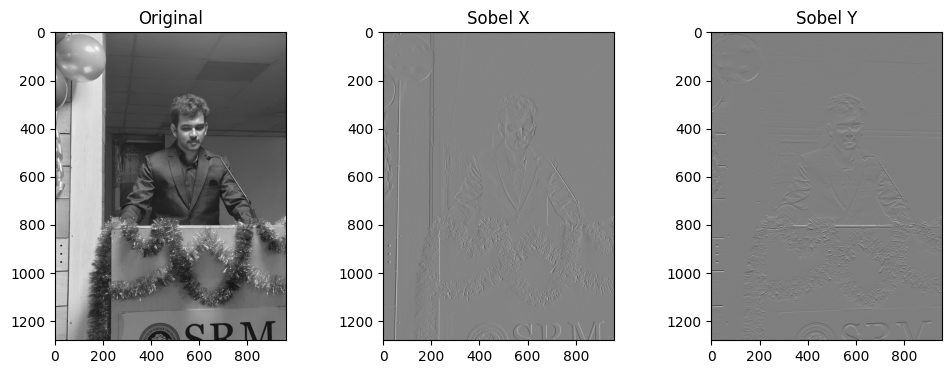

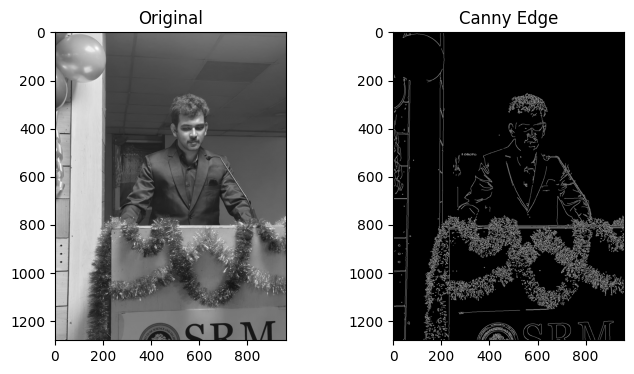

In [1]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/image.jpg"
img = cv2.imread(image_path, 0)

if img is None:
    raise FileNotFoundError(f"Could not load image at {image_path}. Check the file exists and the path is correct.")

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")

plt.subplot(133)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")

plt.show()

# Canny edge detection
edges = cv2.Canny(img, 100, 200)

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge")

plt.show()

B) Sobel Edge Detection

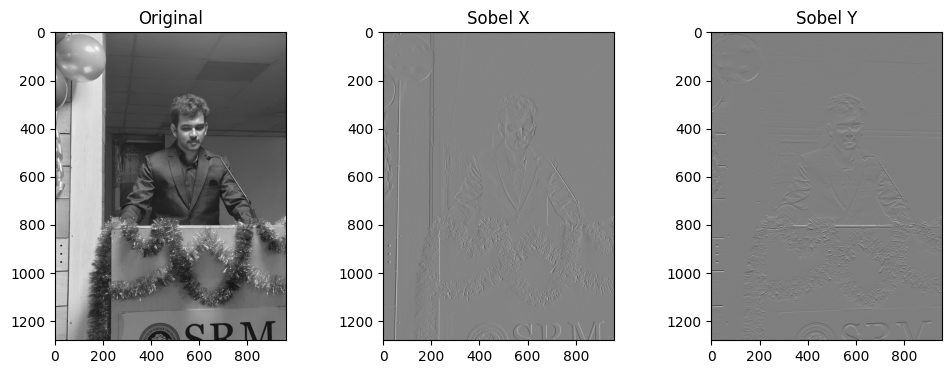

In [2]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/image.jpg"
img = cv2.imread(image_path, 0)

if img is None:
    raise FileNotFoundError(f"Could not load image at {image_path}. Check the file exists and the path is correct.")

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")

plt.subplot(133)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")

plt.show()

Corner Detection
Harris Corner Detection

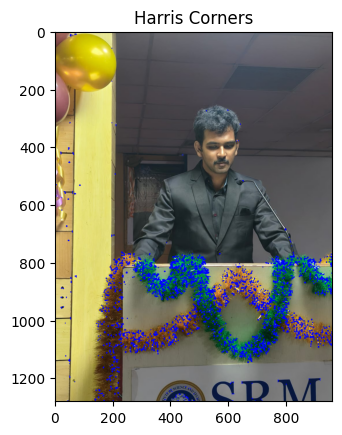

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/image.jpg"
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not load image at {image_path}. Check the file exists and the path is correct.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate to mark the corners more visibly (optional but common practice)
dst = cv2.dilate(dst, None)

img[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Harris Corners")
plt.show()

Interest Point Detection
SIFT Feature Detection

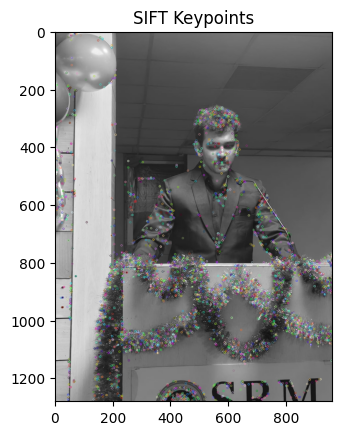

In [4]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/image.jpg"
img = cv2.imread(image_path, 0)

if img is None:
    raise FileNotFoundError(f"Could not load image at {image_path}. Check the file exists and the path is correct.")

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(img, None)

output = cv2.drawKeypoints(img, keypoints, None)

plt.imshow(output, cmap='gray')
plt.title("SIFT Keypoints")
plt.show()

4. Mathematical Morphology

Suppose the binary image contains white objects.

A) Dilation

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("binary.png",0)

kernel = np.ones((5,5),np.uint8)

dilation = cv2.dilate(img,kernel,iterations=1)

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(dilation,cmap='gray')
plt.title("Dilated")

plt.show()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/morph.dispatch.cpp:1066: error: (-215:Assertion failed) !src.empty() in function 'dilate'


B) Erosion

In [8]:
erosion = cv2.erode(img,kernel,iterations=1)

plt.imshow(erosion,cmap='gray')
plt.title("Erosion")
plt.show()

NameError: name 'kernel' is not defined

C) Opening

In [ ]:
opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)

plt.imshow(opening,cmap='gray')
plt.title("Opening")
plt.show()

5. Texture Analysis
Local Binary Pattern (LBP)

In [ ]:
from skimage.feature import local_binary_pattern
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg",0)

radius = 3
points = 8*radius

lbp = local_binary_pattern(image,points,radius,method='uniform')

plt.subplot(121)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(lbp,cmap='gray')
plt.title("LBP Texture")

plt.show()

Combined Program (Edge + Corner + Morphology)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Edge Detection
edges = cv2.Canny(gray,100,200)

# Harris Corner
grayf = np.float32(gray)
corners = cv2.cornerHarris(grayf,2,3,0.04)

corner_img = img.copy()
corner_img[corners>0.01*corners.max()] = [0,0,255]

# Morphology
kernel = np.ones((5,5),np.uint8)
dilate = cv2.dilate(edges,kernel)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(edges,cmap='gray')
plt.title("Edges")

plt.subplot(132)
plt.imshow(cv2.cvtColor(corner_img,cv2.COLOR_BGR2RGB))
plt.title("Corners")

plt.subplot(133)
plt.imshow(dilate,cmap='gray')
plt.title("Dilated Edge")

plt.show()